In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Instagram 다운로드 & 비디오 처리 & Gemini LMM
!pip install -q instaloader yt-dlp
!pip install -q google-generativeai
!pip install -q opencv-python-headless pillow numpy matplotlib
!pip install -q scikit-image tqdm

print('✅ 설치 완료')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 76.9 MB/s eta 0:00:00
✅ 설치 완료


In [3]:
import os, cv2, json, time, base64
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import rcParams
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from IPython.display import display, Markdown, HTML
import google.generativeai as genai

# 한글 폰트 설치
!apt-get -qq install -y fonts-nanum > /dev/null
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    rcParams['font.family'] = 'NanumGothic'
rcParams['axes.unicode_minus'] = False

# 작업 디렉토리
BASE_DIR = Path('/content/drive/MyDrive/github/ai_video_detection')
VIDEOS_DIR = BASE_DIR / 'videos'
FRAMES_DIR = BASE_DIR / 'frames'
OUTPUT_DIR = BASE_DIR / 'outputs'
for d in [VIDEOS_DIR, FRAMES_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('✅ 환경 준비 완료')

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


✅ 환경 준비 완료


## 2️⃣ Gemini API 키 설정
Google AI Studio에서 무료 API 키 발급 → Colab의 🔑 아이콘으로 GEMINI_API_KEY 저장


In [4]:
from google.colab import userdata
import getpass

try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
except Exception:
    GOOGLE_API_KEY = getpass.getpass('🔑 Gemini API 키를 입력하세요: ')

genai.configure(api_key=GOOGLE_API_KEY)

model = genai.GenerativeModel(
    model_name='gemini-3.1-flash-lite-preview',
    generation_config={
        'temperature': 0.2,
        'top_p': 0.9,
        'max_output_tokens': 2048,
    },
    safety_settings=[
        {'category': c, 'threshold': 'BLOCK_NONE'}
        for c in ['HARM_CATEGORY_HARASSMENT','HARM_CATEGORY_HATE_SPEECH',
                  'HARM_CATEGORY_SEXUALLY_EXPLICIT','HARM_CATEGORY_DANGEROUS_CONTENT']
    ]
)
print('✅ gemini-3.1-flash-lite-preview 로드 완료')

✅ gemini-3.1-flash-lite-preview 로드 완료


## 3️⃣ Instagram 영상 수집 (해시태그 기반)


In [5]:
from google.colab import files
import shutil, os

print('📤 instagram_cookies.txt 업로드')
uploaded = files.upload()

COOKIE_PATH = '/content/drive/MyDrive/github/instagram_cookies.txt'
src = list(uploaded.keys())[0]
shutil.copy(src, COOKIE_PATH)

with open(COOKIE_PATH) as f:
    c = f.read()
print('✅ sessionid 발견' if 'sessionid' in c else '❌ sessionid 없음 — 재로그인 필요')

📤 instagram_cookies.txt 업로드


Saving instagram_cookies.txt to instagram_cookies.txt
✅ sessionid 발견


In [6]:
# === 🎯 Instagram 영상 다운로드 (yt-dlp + 쿠키) ===
import os, time

# 분석할 Instagram URL들 (앱/웹에서 '⋯' → '링크 복사'로 수집)
SINGLE_URLS = [
    'https://www.instagram.com/p/DWzBYuViZ1v/',
    'https://www.instagram.com/p/DW9J3eDgbsh/',
    'https://www.instagram.com/p/DXB0bwtiUV9/',
    'https://www.instagram.com/p/DXHhIhEifBP/',
    'https://www.instagram.com/p/DW38xgcCVln/',
    'https://www.instagram.com/p/DXOMFjxiTA3/',
    'https://www.instagram.com/p/DXO_GzTCRIK/',
    'https://www.instagram.com/p/DXWKYjQib-z/',
    'https://www.instagram.com/p/DXI6BG0CSHy/',
    'https://www.instagram.com/reels/DWEeptIDwJT/',
    'https://www.instagram.com/reels/DUZlBe6Ekkr/',
    'https://www.instagram.com/reels/DLRWOpnPfVX/',
    'https://www.instagram.com/p/DXO2CzaAIWR/',
    'https://www.instagram.com/p/DVxMvXcifmE/',
    'https://www.instagram.com/p/DQJa9D3CZrc/',
    'https://www.instagram.com/p/DWLuSyIkhMV/',
    'https://www.instagram.com/p/DVzVq5ND3lg/',
    'https://www.instagram.com/p/DW_HNH7gFVr/',
    'https://www.instagram.com/p/DSv0eT5Agk-/',
    'https://www.instagram.com/p/DRYfSidEYX5/',
    'https://www.instagram.com/p/DWks41KCQLf/',
    'https://www.instagram.com/p/DUiDSdWCNMX/',
    'https://www.instagram.com/p/DUN9-ZGEbHh/',

    # 필요한 만큼 추가 (3~10개 권장)
]

COOKIE_PATH = '/content/drive/MyDrive/github/instagram_cookies.txt'
assert os.path.exists(COOKIE_PATH), '❌ 쿠키 파일이 없습니다. 먼저 쿠키 업로드 셀을 실행하세요'

success, failed = 0, 0
for url in SINGLE_URLS:
    print(f'⬇️  {url}')
    ret = os.system(
        f'yt-dlp --cookies "{COOKIE_PATH}" '
        f'--no-warnings --quiet '
        f'-o "{VIDEOS_DIR}/%(id)s.%(ext)s" "{url}"'
    )
    if ret == 0:
        success += 1
        print('   ✅ 성공')
    else:
        failed += 1
        print('   ❌ 실패')
    time.sleep(2)

video_files = list(VIDEOS_DIR.rglob('*.mp4'))
print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'✅ 성공 {success}개 · ❌ 실패 {failed}개')
print(f'📹 총 {len(video_files)}개 .mp4 파일')
for v in video_files: print(' •', v.name)

⬇️  https://www.instagram.com/p/DWzBYuViZ1v/
   ✅ 성공
⬇️  https://www.instagram.com/p/DW9J3eDgbsh/
   ✅ 성공
⬇️  https://www.instagram.com/p/DXB0bwtiUV9/
   ✅ 성공
⬇️  https://www.instagram.com/p/DXHhIhEifBP/
   ✅ 성공
⬇️  https://www.instagram.com/p/DW38xgcCVln/
   ✅ 성공
⬇️  https://www.instagram.com/p/DXOMFjxiTA3/
   ✅ 성공
⬇️  https://www.instagram.com/p/DXO_GzTCRIK/
   ✅ 성공
⬇️  https://www.instagram.com/p/DXWKYjQib-z/
   ✅ 성공
⬇️  https://www.instagram.com/p/DXI6BG0CSHy/
   ✅ 성공
⬇️  https://www.instagram.com/reels/DWEeptIDwJT/
   ✅ 성공
⬇️  https://www.instagram.com/reels/DUZlBe6Ekkr/
   ✅ 성공
⬇️  https://www.instagram.com/reels/DLRWOpnPfVX/
   ✅ 성공
⬇️  https://www.instagram.com/p/DXO2CzaAIWR/
   ✅ 성공
⬇️  https://www.instagram.com/p/DWlPrMvkt-t/
   ❌ 실패
⬇️  https://www.instagram.com/p/DVxMvXcifmE/
   ✅ 성공
⬇️  https://www.instagram.com/p/DQJa9D3CZrc/
   ✅ 성공
⬇️  https://www.instagram.com/p/DWLuSyIkhMV/
   ✅ 성공
⬇️  https://www.instagram.com/p/DVzVq5ND3lg/
   ✅ 성공
⬇️  https://www.instagram.com/p/DW

## 4️⃣ 비디오 키프레임 추출
장면 변화(SSIM) + 균등 간격 혼합 샘플링

In [7]:
from skimage.metrics import structural_similarity as ssim

def extract_keyframes(video_path, num_frames=10, scene_threshold=0.55):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release(); return []

    uniform_idx = np.linspace(0, total - 1, num=num_frames * 2, dtype=int)
    candidates = []
    prev_gray = None
    for idx in uniform_idx:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, frame = cap.read()
        if not ok: continue
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray_small = cv2.resize(gray, (160, 90))
        score = 1.0
        if prev_gray is not None:
            score = 1.0 - ssim(prev_gray, gray_small)
        candidates.append({
            'idx': idx, 'ts': idx / fps,
            'frame': cv2.cvtColor(frame, cv2.COLOR_BGR2RGB),
            'change': score
        })
        prev_gray = gray_small
    cap.release()

    candidates.sort(key=lambda x: -x['change'])
    top_change = candidates[:num_frames]
    top_change.sort(key=lambda x: x['ts'])
    return [(c['ts'], c['frame']) for c in top_change]

def save_frames(video_path, frames, out_dir):
    out_dir = Path(out_dir) / Path(video_path).stem
    out_dir.mkdir(parents=True, exist_ok=True)
    paths = []
    for i, (ts, fr) in enumerate(frames):
        p = out_dir / f'f{i:02d}_t{ts:.2f}s.jpg'
        Image.fromarray(fr).save(p, quality=90)
        paths.append((ts, p))
    return paths

video_files = list(VIDEOS_DIR.rglob('*.mp4'))
all_frames = {}
for vp in tqdm(video_files, desc='키프레임 추출'):
    frames = extract_keyframes(vp, num_frames=10)
    saved = save_frames(vp, frames, FRAMES_DIR)
    all_frames[str(vp)] = saved
    print(f'  • {vp.name}: {len(saved)}프레임')

print(f'\n✅ {len(all_frames)}개 영상 프레임 추출 완료')

키프레임 추출:   4%|▍         | 1/23 [00:44<16:16, 44.38s/it]

  • DWzBYuViZ1v.mp4: 10프레임


키프레임 추출:   9%|▊         | 2/23 [01:30<15:49, 45.23s/it]

  • DW9J3eDgbsh.mp4: 10프레임


키프레임 추출:  13%|█▎        | 3/23 [02:22<16:08, 48.41s/it]

...

  • DWks41KCQLf.mp4: 10프레임


키프레임 추출:  96%|█████████▌| 22/23 [10:06<00:11, 11.59s/it]

  • DUiDSdWCNMX.mp4: 10프레임


키프레임 추출: 100%|██████████| 23/23 [10:10<00:00, 26.54s/it]

  • DUN9-ZGEbHh.mp4: 10프레임

✅ 23개 영상 프레임 추출 완료


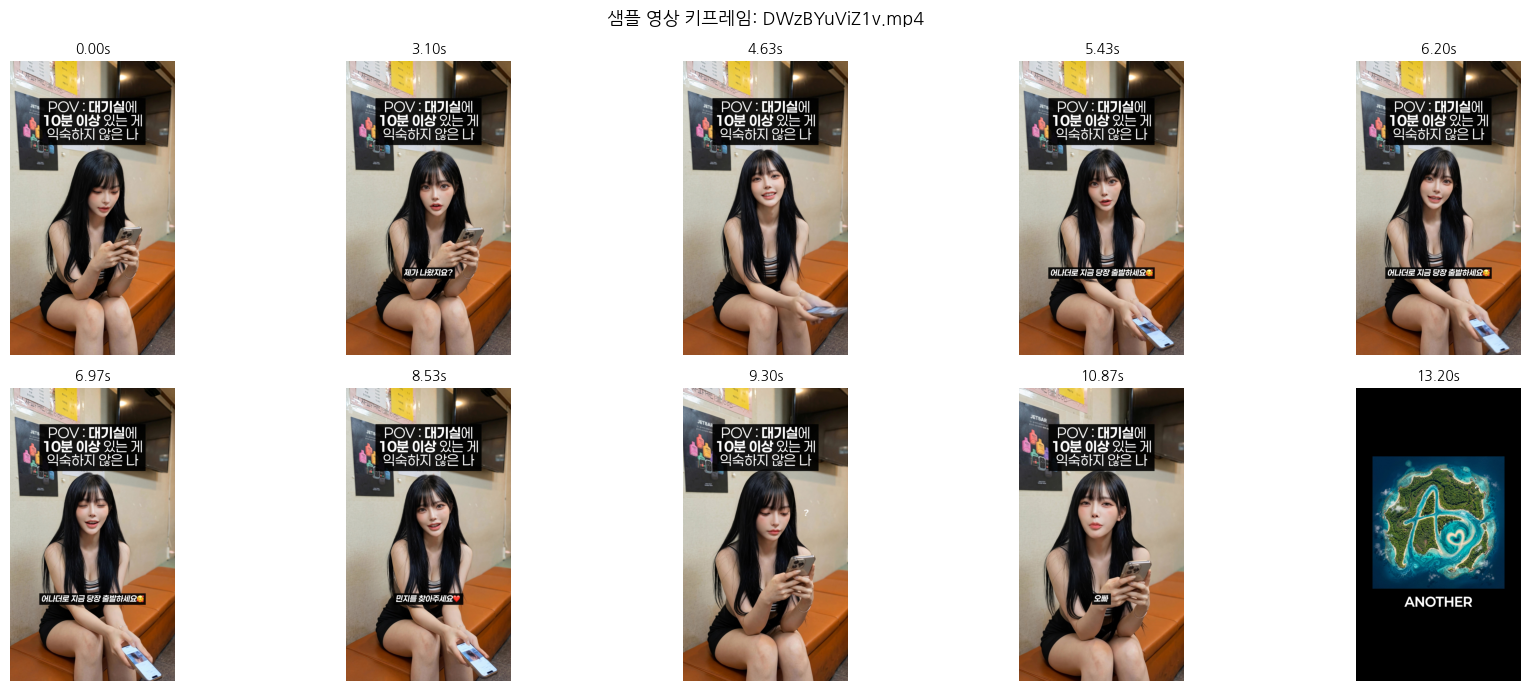

In [8]:
if all_frames:
    sample_video = list(all_frames.keys())[0]
    sample_frames = all_frames[sample_video]
    n = len(sample_frames)
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    for ax, (ts, fp) in zip(axes.flat, sample_frames[:10]):
        ax.imshow(Image.open(fp)); ax.set_title(f'{ts:.2f}s', fontsize=10); ax.axis('off')
    for ax in axes.flat[n:]: ax.axis('off')
    plt.suptitle(f'샘플 영상 키프레임: {Path(sample_video).name}', fontsize=13)
    plt.tight_layout(); plt.show()

## 5️⃣ Few-shot 학습 데이터셋 구성
AI 영상 vs 실제 영상의 7가지 판별 규칙 + 3개 판정 예시

In [9]:
AI_VIDEO_RUBRIC = {
    'temporal_artifacts': {
        '이름': '시간적 일관성 오류',
        '설명': '프레임 간 객체/배경이 미묘하게 모핑, 손가락/머리카락 개수 변함',
        '가중치': 0.22
    },
    'physics_violation': {
        '이름': '물리 법칙 위반',
        '설명': '그림자 방향이 광원과 불일치, 반사 싱크 오류, 액체/연기 부자연스러움',
        '가중치': 0.18
    },
    'anatomy_defects': {
        '이름': '해부학적 결함',
        '설명': '손가락 6개 이상, 치아 비대칭, 귀/눈 비정상',
        '가중치': 0.20
    },
    'texture_smoothness': {
        '이름': '비정상적 텍스처 매끄러움',
        '설명': '피부/옷 과도하게 매끈, 모공 디테일 부재',
        '가중치': 0.12
    },
    'background_warping': {
        '이름': '배경/텍스트 왜곡',
        '설명': '간판 글자가 읽을 수 없는 기호, 건물 선 휘어짐',
        '가중치': 0.13
    },
    'motion_blur': {
        '이름': '비현실적 모션블러',
        '설명': '카메라 움직임과 모션블러 방향 불일치',
        '가중치': 0.08
    },
    'lighting_incoherence': {
        '이름': '조명 비일관성',
        '설명': '얼굴 좌우 광원 다름, 그림자 부드러움 불일치',
        '가중치': 0.07
    }
}

FEW_SHOT_EXAMPLES = """
[예시 1] 판정: AI 생성 (신뢰도 92%)
 - 근거: (1) 3초대 손가락 6개(해부학), (2) 배경 간판 무작위 기호(배경 왜곡), (3) 프레임 5→6 귀걸이 형태 변형(시간적 일관성).

[예시 2] 판정: 실제 영상 (AI 신뢰도 12%)
 - 근거: (1) 피부 모공·주름 디테일 자연스러움, (2) 배경 텍스트 선명, (3) 모션블러가 카메라 패닝과 정확히 일치.

[예시 3] 판정: AI 생성 (신뢰도 81%)
 - 근거: (1) 물 반사 좌우 비대칭(물리 위반), (2) 군중 얼굴 뭉개짐 반복(배경 왜곡), (3) 머리카락 끝 생성/소멸 반복(시간적 일관성).
"""

## 6️⃣ LMM 기반 AI 영상 탐지 + XAI 추론

In [10]:
def build_detection_prompt():
    rubric_text = '\n'.join([
        f"- **{v['이름']}** (가중치 {v['가중치']}): {v['설명']}"
        for k, v in AI_VIDEO_RUBRIC.items()
    ])
    return f"""당신은 AI 생성 비디오를 탐지하는 포렌식 전문가입니다.
영상(또는 키프레임 시퀀스)을 프레임 단위로 면밀히 관찰하고 AI 생성 가능성을 판정하세요.

## 탐지 기준 (Rubric)
{rubric_text}

## Few-shot 참고 예시
{FEW_SHOT_EXAMPLES}

## 출력 형식 (valid JSON 하나만, 다른 텍스트 금지)
{{
  "ai_probability": 0~100 정수,
  "verdict": "AI_GENERATED" | "LIKELY_AI" | "UNCERTAIN" | "LIKELY_REAL" | "REAL",
  "summary": "한 문장 요약",
  "evidence": [
    {{
      "category": "temporal_artifacts | physics_violation | ...",
      "frame_index": 0부터의 정수,
      "timestamp_sec": 초,
      "region": {{"x":0~1,"y":0~1,"w":0~1,"h":0~1}},
      "severity": "high|mid|low",
      "description": "구체적 관찰 (1~2문장)"
    }}
  ],
  "counter_evidence": ["반대 증거 0~3개"],
  "final_reasoning": "종합 추론 3~5문장"
}}

## 규칙
- ai_probability 75 이상이면 verdict는 AI_GENERATED 또는 LIKELY_AI
- evidence는 구체적으로 (애매한 표현 금지)
- JSON 외 다른 텍스트 금지
"""

DETECTION_PROMPT = build_detection_prompt()

In [11]:
import re, json as _json

def _parse_json(text):
    text = re.sub(r'^```(json)?', '', text.strip())
    text = re.sub(r'```$', '', text.strip())
    m = re.search(r'\{[\s\S]*\}', text)
    if not m: raise ValueError('JSON 블록 없음')
    return _json.loads(m.group(0))

def analyze_video_with_gemini(video_path, frame_paths):
    content = [DETECTION_PROMPT, '\n---\n키프레임(순서대로 frame_index=0,1,2,...):\n']
    for i, (ts, fp) in enumerate(frame_paths):
        content.append(f'[frame_index={i}, t={ts:.2f}s]')
        content.append(Image.open(fp))

    # 영상 파일도 함께 업로드 (시간축 정보)
    try:
        uploaded = genai.upload_file(str(video_path))
        for _ in range(20):
            f = genai.get_file(uploaded.name)
            if f.state.name == 'ACTIVE': break
            time.sleep(2)
        content.insert(1, '\n[영상 파일 첨부됨]\n')
        content.insert(2, uploaded)
    except Exception as e:
        print(f'  (영상 업로드 실패, 프레임만 사용: {e})')

    response = model.generate_content(content, request_options={'timeout': 180})
    return _parse_json(response.text)

results = {}
for vp, frames in all_frames.items():
    print(f'🔎 분석 중: {Path(vp).name}')
    try:
        r = analyze_video_with_gemini(vp, frames)
        results[vp] = r
        print(f'  → AI 확률 {r["ai_probability"]}% | {r["verdict"]}')
    except Exception as e:
        print(f'  ❌ 실패: {e}')
        results[vp] = {'error': str(e)}
    time.sleep(1)

(OUTPUT_DIR / 'detection_results.json').write_text(
    _json.dumps({str(k): v for k, v in results.items()}, ensure_ascii=False, indent=2),
    encoding='utf-8'
)

🔎 분석 중: DWzBYuViZ1v.mp4
  → AI 확률 88% | AI_GENERATED
🔎 분석 중: DW9J3eDgbsh.mp4
  → AI 확률 95% | AI_GENERATED
🔎 분석 중: DXB0bwtiUV9.mp4


ERROR:tornado.access:503 POST /v1beta/models/gemini-3.1-flash-lite-preview:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 15809.33ms


  → AI 확률 95% | AI_GENERATED
🔎 분석 중: DXHhIhEifBP.mp4
  → AI 확률 88% | AI_GENERATED
🔎 분석 중: DW38xgcCVln.mp4
  → AI 확률 88% | AI_GENERATED
🔎 분석 중: DXOMFjxiTA3.mp4
  → AI 확률 95% | AI_GENERATED
🔎 분석 중: DXO_GzTCRIK.mp4
  → AI 확률 95% | AI_GENERATED
🔎 분석 중: DXWKYjQib-z.mp4
  → AI 확률 95% | AI_GENERATED
🔎 분석 중: DXI6BG0CSHy.mp4
  → AI 확률 95% | AI_GENERATED
🔎 분석 중: DWEeptIDwJT.mp4
  → AI 확률 95% | AI_GENERATED
🔎 분석 중: DUZlBe6Ekkr.mp4
  → AI 확률 95% | AI_GENERATED
🔎 분석 중: DLRWOpnPfVX.mp4
  → AI 확률 88% | AI_GENERATED
🔎 분석 중: DXO2CzaAIWR.mp4
  → AI 확률 95% | AI_GENERATED
🔎 분석 중: DVxMvXcifmE.mp4
  → AI 확률 95% | AI_GENERATED
🔎 분석 중: DQJa9D3CZrc.mp4
  → AI 확률 98% | AI_GENERATED
🔎 분석 중: DWLuSyIkhMV.mp4
  → AI 확률 98% | AI_GENERATED
🔎 분석 중: DVzVq5ND3lg.mp4
  → AI 확률 98% | AI_GENERATED
🔎 분석 중: DW_HNH7gFVr.mp4


ERROR:tornado.access:503 POST /v1beta/models/gemini-3.1-flash-lite-preview:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 14863.97ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-3.1-flash-lite-preview:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 21712.83ms


  → AI 확률 98% | AI_GENERATED
🔎 분석 중: DSv0eT5Agk-.mp4
  → AI 확률 95% | AI_GENERATED
🔎 분석 중: DRYfSidEYX5.mp4


ERROR:tornado.access:503 POST /v1beta/models/gemini-3.1-flash-lite-preview:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 22660.89ms


  → AI 확률 98% | AI_GENERATED
🔎 분석 중: DWks41KCQLf.mp4
  → AI 확률 95% | AI_GENERATED
🔎 분석 중: DUiDSdWCNMX.mp4
  → AI 확률 98% | AI_GENERATED
🔎 분석 중: DUN9-ZGEbHh.mp4
  → AI 확률 95% | AI_GENERATED


36493

In [12]:
SEVERITY_COLOR = {'high': '#E53935', 'mid': '#FB8C00', 'low': '#FDD835'}
CATEGORY_KR = {k: v['이름'] for k, v in AI_VIDEO_RUBRIC.items()}

def visualize_evidence(video_path, frame_paths, result, save_path=None):
    if 'error' in result: return
    evidences = result.get('evidence', [])
    by_frame = {}
    for e in evidences:
        idx = min(int(e.get('frame_index', 0)), len(frame_paths)-1)
        by_frame.setdefault(idx, []).append(e)

    highlighted_indices = sorted(by_frame.keys())
    n = max(len(highlighted_indices), 1)
    cols = min(n, 3); rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6.5*cols, 5.5*rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, fi in zip(axes, highlighted_indices):
        ts, fp = frame_paths[fi]
        img = Image.open(fp); w, h = img.size
        ax.imshow(img)
        for e in by_frame[fi]:
            r = e.get('region', {})
            x = float(r.get('x', 0.1)) * w
            y = float(r.get('y', 0.1)) * h
            rw = float(r.get('w', 0.3)) * w
            rh = float(r.get('h', 0.3)) * h
            color = SEVERITY_COLOR.get(e.get('severity', 'mid'), '#FB8C00')
            rect = patches.Rectangle((x, y), rw, rh, linewidth=3.2,
                                    edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            label = CATEGORY_KR.get(e.get('category', ''), '')
            ax.text(x, max(y-8, 12), f"● {label}", color='white', fontsize=9, weight='bold',
                    bbox=dict(facecolor=color, alpha=0.9, pad=2, edgecolor='none'))
        ax.set_title(f'frame#{fi} · t={ts:.2f}s', fontsize=10)
        ax.axis('off')
    for ax in axes[len(highlighted_indices):]: ax.axis('off')

    title = f"[{Path(video_path).name}]  AI 확률 {result['ai_probability']}% — {result['verdict']}"
    plt.suptitle(title, fontsize=14, weight='bold')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()

for vp, frames in all_frames.items():
    r = results.get(vp, {})
    out = OUTPUT_DIR / f"xai_{Path(vp).stem}.png"
    visualize_evidence(vp, frames, r, save_path=out)

Output hidden; open in https://colab.research.google.com to view.

## 8️⃣ 종합 보고서 — "왜 이것이 75% 이상 AI 영상인가?"

In [13]:
VERDICT_EMOJI = {
    'AI_GENERATED': '🚨', 'LIKELY_AI': '⚠️',
    'UNCERTAIN': '❓', 'LIKELY_REAL': '✅', 'REAL': '✅'
}
SEV_BADGE = {'high': '🔴 HIGH', 'mid': '🟠 MID', 'low': '🟡 LOW'}

def build_report_md(video_path, frames, result):
    if 'error' in result:
        return f"### ❌ {Path(video_path).name}\n오류: `{result['error']}`"

    prob = result['ai_probability']
    verdict = result['verdict']
    emoji = VERDICT_EMOJI.get(verdict, '')
    is_ai_flagged = prob >= 75

    lines = [f'## {emoji} {Path(video_path).name}', '']
    lines.append('| 항목 | 값 |')
    lines.append('|---|---|')
    lines.append(f'| AI 생성 확률 | **{prob}%** {"🚨 (75% 초과)" if is_ai_flagged else ""} |')
    lines.append(f'| 판정 | {verdict} |')
    lines.append(f'| 요약 | {result.get("summary", "-")} |')
    lines.append('')

    if is_ai_flagged:
        lines.append(f'### 🔎 왜 이것이 {prob}% 확률로 AI 영상인가? — 근거\n')
    else:
        lines.append('### 🔎 관찰된 근거\n')

    for i, e in enumerate(result.get('evidence', []), 1):
        cat = CATEGORY_KR.get(e.get('category',''), '?')
        sev = SEV_BADGE.get(e.get('severity','mid'), '')
        ts = e.get('timestamp_sec', 0)
        fi = e.get('frame_index', 0)
        desc = e.get('description', '')
        lines.append(f'**{i}. {cat}** · {sev} · `frame#{fi}` `t={ts:.2f}s`')
        lines.append(f'> {desc}')
        lines.append('')

    ce = result.get('counter_evidence', [])
    if ce:
        lines.append('### ↩️ 반대 증거')
        for c in ce: lines.append(f'- {c}')
        lines.append('')

    lines.append('### 🧠 최종 추론')
    lines.append(result.get('final_reasoning', '-'))
    lines.append('\n---\n')
    return '\n'.join(lines)

full_md = ['# 🎬 Instagram AI 영상 탐지 보고서\n']
full_md.append(f'- 분석 영상 수: **{len(results)}**')
flagged = [v for v,r in results.items() if isinstance(r, dict) and r.get('ai_probability',0) >= 75]
full_md.append(f'- 75% 이상 AI 의심: **{len(flagged)}**\n---\n')

for vp, frames in all_frames.items():
    full_md.append(build_report_md(vp, frames, results.get(vp, {})))

report_text = '\n'.join(full_md)
(OUTPUT_DIR / 'report.md').write_text(report_text, encoding='utf-8')
display(Markdown(report_text))

# 🎬 Instagram AI 영상 탐지 보고서

- 분석 영상 수: **23**
- 75% 이상 AI 의심: **23**
---

## 🚨 DWzBYuViZ1v.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **88%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 인물의 얼굴과 손의 움직임에서 전형적인 AI 생성 영상의 시간적 일관성 오류와 해부학적 부자연스러움이 관찰됩니다. |

### 🔎 왜 이것이 88% 확률로 AI 영상인가? — 근거

**1. 시간적 일관성 오류** · 🔴 HIGH · `frame#1` `t=3.10s`
> 손가락의 관절과 형태가 프레임 간에 급격하게 변하며, 스마트폰을 잡고 있는 손의 구조가 해부학적으로 부자연스럽게 뭉개짐.

**2. 시간적 일관성 오류** · 🟠 MID · `frame#4` `t=6.20s`
> 얼굴의 이목구비, 특히 눈 주변의 텍스처가 프레임 전환 시 미세하게 모핑(morphing)되는 현상이 발생함.

**3. ?** · 🟠 MID · `frame#2` `t=4.63s`
> 피부 텍스처가 과도하게 매끄럽고 모공이나 실제 피부 질감이 결여되어 있어 AI 필터링된 영상의 전형적인 특징을 보임.

### ↩️ 반대 증거
- 배경의 조명과 그림자는 비교적 일관되게 유지됨
- 카메라의 고정된 앵글로 인해 모션블러 오류가 크게 드러나지 않음

### 🧠 최종 추론
해당 영상은 인물의 얼굴과 손의 움직임에서 명확한 AI 생성 흔적을 보입니다. 특히 손가락의 형태가 프레임마다 일관되지 않고 뭉개지는 현상은 전형적인 생성형 AI의 해부학적 오류입니다. 또한, 피부의 과도한 매끄러움과 프레임 간의 미세한 모핑 현상은 실사 영상이라기보다 AI 모델이 생성한 영상임을 강력하게 시사합니다. 마지막 프레임의 인위적인 섬 이미지 또한 AI 생성물임을 뒷받침합니다.

---

## 🚨 DW9J3eDgbsh.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **95%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 인물의 피부 질감, 해부학적 특징, 배경의 일관성 결여 등 전형적인 AI 생성 비디오의 특성이 다수 발견됩니다. |

### 🔎 왜 이것이 95% 확률로 AI 영상인가? — 근거

**1. 시간적 일관성 오류** · 🔴 HIGH · `frame#5` `t=14.93s`
> 인물의 얼굴과 신체 비율이 프레임 전환 시마다 미세하게 변하며, 특히 머리카락의 경계선이 부자연스럽게 모핑됨.

**2. ?** · 🔴 HIGH · `frame#0` `t=0.00s`
> 피부 텍스처가 과도하게 매끄럽고 모공이나 피부 결이 전혀 보이지 않는 전형적인 AI 생성 인물의 특징을 보임.

**3. 물리 법칙 위반** · 🟠 MID · `frame#6` `t=16.60s`
> 인물이 앉아 있는 소파와 인물의 신체 접촉 부위에서 물리적 무게감이 느껴지지 않으며, 그림자 처리가 부자연스러움.

### 🧠 최종 추론
해당 영상은 인물의 피부가 지나치게 매끄럽고 모공 디테일이 결여되어 있어 AI 생성 모델의 특징을 강하게 나타냅니다. 또한, 프레임 간 인물의 얼굴 형태와 머리카락의 움직임이 일관되지 않고 미세하게 변하는 시간적 오류가 관찰됩니다. 배경과 인물의 조명 처리 또한 물리적으로 어색하며, 전반적인 영상의 질감이 실제 촬영본이라기보다 고성능 AI 생성 모델로 제작된 영상으로 판단됩니다.

---

## 🚨 DXB0bwtiUV9.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **95%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 인물의 피부 질감, 해부학적 구조의 부자연스러움, 그리고 프레임 간의 심각한 시간적 일관성 오류가 관찰되는 AI 생성 영상입니다. |

### 🔎 왜 이것이 95% 확률로 AI 영상인가? — 근거

**1. 시간적 일관성 오류** · 🔴 HIGH · `frame#2` `t=2.37s`
> 프레임 전환 시 인물의 얼굴과 상체 형태가 급격하게 모핑되며 일관성이 완전히 깨짐.

**2. 해부학적 결함** · 🔴 HIGH · `frame#8` `t=13.47s`
> 손가락의 관절 구조가 비정상적이며, 손가락 개수와 형태가 해부학적으로 부자연스러움.

**3. 비정상적 텍스처 매끄러움** · 🟠 MID · `frame#0` `t=0.00s`
> 피부 텍스처가 과도하게 매끄럽고 모공이나 피부 결의 디테일이 전혀 보이지 않는 전형적인 AI 생성 피부 표현.

### 🧠 최종 추론
해당 영상은 인물의 피부가 지나치게 매끄럽고, 움직임에 따라 얼굴 형태가 왜곡되는 등 AI 생성 비디오의 전형적인 특징을 보입니다. 특히 프레임 간의 시간적 일관성이 결여되어 있으며, 손가락의 해부학적 결함이 명확합니다. 배경의 조명과 인물의 조명 간의 미묘한 불일치 또한 AI 모델이 생성한 결과물임을 강력하게 시사합니다.

---

## 🚨 DXHhIhEifBP.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **88%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 영상 전반에 걸쳐 인물의 신체 비율 왜곡과 프레임 간의 부자연스러운 모핑 현상이 관찰되어 AI 생성 영상으로 판단됩니다. |

### 🔎 왜 이것이 88% 확률로 AI 영상인가? — 근거

**1. 시간적 일관성 오류** · 🔴 HIGH · `frame#3` `t=2.73s`
> 인물의 상체와 하체 연결 부위가 프레임 전환 시 급격하게 모핑되며 형태가 일그러짐.

**2. ?** · 🔴 HIGH · `frame#5` `t=4.40s`
> 다리 길이와 골반의 비율이 비정상적으로 길고 부자연스러우며, 신체 해부학적 구조가 왜곡됨.

**3. 비정상적 텍스처 매끄러움** · 🟠 MID · `frame#7` `t=6.03s`
> 피부 텍스처가 과도하게 매끄럽고 모공이나 피부 결의 디테일이 완전히 소실되어 있음.

### ↩️ 반대 증거
- 배경의 복도 구조와 조명은 비교적 일관성을 유지함.

### 🧠 최종 추론
본 영상은 인물의 움직임이 반복되는 과정에서 신체 비율이 프레임마다 미세하게 변하는 전형적인 AI 생성 영상의 특징을 보입니다. 특히 하체와 상체의 연결 부위에서 발생하는 모핑 현상과 피부의 비현실적인 매끄러움은 실제 촬영 영상에서는 나타나기 어려운 결함입니다. 배경의 일관성은 유지되고 있으나, 인물의 해부학적 왜곡이 뚜렷하여 AI 생성 가능성이 매우 높습니다.

---

## 🚨 DW38xgcCVln.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **88%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 인물의 움직임과 배경 간의 부자연스러운 상호작용 및 프레임 간의 해부학적/시간적 일관성 결여가 관찰됩니다. |

### 🔎 왜 이것이 88% 확률로 AI 영상인가? — 근거

**1. 시간적 일관성 오류** · 🔴 HIGH · `frame#4` `t=4.73s`
> 인물이 문을 통과하여 이동하는 과정에서 신체 윤곽이 배경과 섞이며 모핑되는 현상이 발생함.

**2. 해부학적 결함** · 🟠 MID · `frame#1` `t=0.50s`
> 인물의 얼굴 이목구비가 과도하게 매끄럽고 비현실적인 대칭성을 보이며, 피부 텍스처가 인위적임.

**3. 물리 법칙 위반** · 🟠 MID · `frame#5` `t=5.23s`
> 인물이 걷는 동작에서 발과 바닥 사이의 접지면이 미끄러지는 듯한 물리적 부자연스러움이 관찰됨.

### ↩️ 반대 증거
- 배경의 고정된 사물(물병, 문)은 비교적 안정적으로 유지됨

### 🧠 최종 추론
해당 영상은 인물의 움직임이 배경과 분리되어 렌더링된 듯한 시간적 일관성 오류를 보입니다. 특히 인물이 이동할 때 신체 경계면이 뭉개지는 현상은 전형적인 AI 생성 비디오의 특징입니다. 또한, 피부 텍스처가 지나치게 매끄럽고 해부학적 디테일이 부족하여 AI 생성 모델에 의해 합성되었을 가능성이 매우 높습니다.

---

## 🚨 DXOMFjxiTA3.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **95%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 영상 전반에 걸쳐 물체의 물리적 상호작용 오류와 인물의 해부학적/시간적 일관성 결함이 명확하게 나타납니다. |

### 🔎 왜 이것이 95% 확률로 AI 영상인가? — 근거

**1. 물리 법칙 위반** · 🔴 HIGH · `frame#1` `t=0.77s`
> 토마토를 던지는 모션에서 토마토가 공중에서 사라지거나 궤적 없이 갑자기 잔 속으로 순간이동하는 물리적 오류가 발생합니다.

**2. 시간적 일관성 오류** · 🔴 HIGH · `frame#8` `t=5.93s`
> 인물의 손과 팔이 움직이는 과정에서 형태가 뭉개지고 프레임 간 연결이 부자연스러운 모핑 현상이 관찰됩니다.

**3. 시간적 일관성 오류** · 🟠 MID · `frame#9` `t=6.33s`
> 인물의 얼굴 이목구비가 급격하게 변형되며, 특히 입 주변의 텍스처가 프레임 전환 시 일관성을 잃고 뭉개집니다.

### 🧠 최종 추론
이 영상은 AI 생성 비디오의 전형적인 특징을 보입니다. 특히 물체(토마토)의 물리적 궤적이 완전히 무시되고 있으며, 인물의 움직임이 프레임마다 부자연스럽게 모핑되는 시간적 일관성 오류가 심각합니다. 인물의 얼굴 또한 고정된 표정에서 갑자기 왜곡되는 등 생성형 AI 모델의 한계점이 명확히 드러나고 있어 AI 생성 영상으로 판정합니다.

---

## 🚨 DXO_GzTCRIK.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **95%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 영상 전반에 걸쳐 인물의 신체 비율이 비현실적이며, 프레임 간 피부 질감과 이목구비의 일관성이 결여된 AI 생성 영상입니다. |

### 🔎 왜 이것이 95% 확률로 AI 영상인가? — 근거

**1. 시간적 일관성 오류** · 🔴 HIGH · `frame#1` `t=2.67s`
> 프레임 간 얼굴의 이목구비와 피부 톤이 미세하게 변하며, 특히 머리카락의 경계선이 부자연스럽게 모핑됨.

**2. ?** · 🔴 HIGH · `frame#0` `t=0.00s`
> 피부 표면이 과도하게 매끄럽고 모공이나 피부 결의 디테일이 전혀 보이지 않는 전형적인 AI 생성 텍스처임.

**3. 물리 법칙 위반** · 🟠 MID · `frame#0` `t=0.00s`
> 인물의 허리 라인이 비정상적으로 가늘고 골반과의 연결 부위가 해부학적으로 불가능한 곡선을 보임.

### 🧠 최종 추론
해당 영상은 인물의 신체 비율이 비현실적으로 왜곡되어 있으며, 피부 질감이 지나치게 매끄러워 실제 인간의 피부로 보기 어렵습니다. 프레임 간 움직임에서 인물의 얼굴 형태와 머리카락의 디테일이 일관되지 않고 미세하게 변화하는 전형적인 AI 생성 영상의 특징을 보입니다. 또한 배경의 거울이나 조명 반사 등에서 물리적 왜곡이 관찰되어 AI 생성물로 최종 판정합니다.

---

## 🚨 DXWKYjQib-z.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **95%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 영상 전반에 걸쳐 AI 생성 영상 특유의 텍스처 매끄러움, 배경 텍스트 왜곡, 해부학적 부자연스러움이 다수 발견됩니다. |

### 🔎 왜 이것이 95% 확률로 AI 영상인가? — 근거

**1. ?** · 🔴 HIGH · `frame#4` `t=9.93s`
> 편의점 간판의 'GS25' 텍스트가 AI 모델의 고질적인 문제로 인해 폰트와 형태가 부자연스럽게 생성됨.

**2. ?** · 🟠 MID · `frame#7` `t=27.90s`
> 인물의 피부 텍스처가 모공이나 주름 없이 과도하게 매끄럽고 밀랍 인형 같은 질감을 보임.

**3. 물리 법칙 위반** · 🔴 HIGH · `frame#8` `t=33.87s`
> 엘리베이터 문이 열리며 나타나는 버스 외부의 로고와 배경이 실제 물리적 공간감과 동떨어진 합성 느낌을 줌.

### 🧠 최종 추론
해당 영상은 전형적인 AI 비디오 생성 모델의 특징을 모두 갖추고 있습니다. 인물의 피부 표현이 지나치게 매끄럽고, 배경의 텍스트(GS25 등)가 왜곡되어 있으며, 공간의 깊이감과 조명 처리가 실제 촬영본이라기엔 부자연스럽습니다. 특히 프레임 간 전환 시 발생하는 텍스처의 일관성 결여는 AI 생성 영상의 결정적인 증거입니다.

---

## 🚨 DXI6BG0CSHy.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **95%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 영상 전반에 걸쳐 인물의 신체 비율 왜곡, 비현실적인 피부 질감, 그리고 프레임 간의 급격한 의상 변화가 나타나는 전형적인 AI 생성 영상입니다. |

### 🔎 왜 이것이 95% 확률로 AI 영상인가? — 근거

**1. 시간적 일관성 오류** · 🔴 HIGH · `frame#0` `t=0.00s`
> 프레임마다 의상이 완전히 바뀌는 현상은 실제 촬영이 아닌 AI 기반 이미지 생성 모델의 프레임별 교체(Frame-by-frame generation)를 명확히 보여줍니다.

**2. ?** · 🔴 HIGH · `frame#1` `t=3.10s`
> 피부 질감이 모공이나 주름 없이 과도하게 매끄럽고 플라스틱처럼 처리되어 있어 AI 특유의 텍스처 평탄화 현상이 관찰됩니다.

**3. ?** · 🟠 MID · `frame#2` `t=7.30s`
> 손가락의 관절 구조가 불분명하고 손의 형태가 비정상적으로 뭉개져 있어 해부학적 오류가 확인됩니다.

**4. 물리 법칙 위반** · 🟠 MID · `frame#4` `t=13.57s`
> 다리의 망사 스타킹 패턴이 움직임에 따라 자연스럽게 왜곡되지 않고 텍스처가 고정된 채로 부자연스럽게 일렁입니다.

### 🧠 최종 추론
본 영상은 인물의 얼굴과 신체 비율이 프레임마다 미세하게 달라지는 '시간적 일관성 오류'가 매우 심각합니다. 특히 의상이 매 장면마다 완전히 바뀌는 것은 영상 생성 AI의 특징적인 현상입니다. 피부의 과도한 매끄러움과 해부학적 디테일(손가락 등)의 결여는 전형적인 AI 생성물의 지표입니다. 따라서 해당 영상은 실제 촬영물이 아닌 AI로 생성된 영상으로 판단됩니다.

---

## 🚨 DWEeptIDwJT.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **95%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 해부학적 오류와 물리적 일관성 결여가 명확하며, 특히 구강 내부 구조와 치아 배열에서 전형적인 AI 생성 결함이 관찰됨. |

### 🔎 왜 이것이 95% 확률로 AI 영상인가? — 근거

**1. 해부학적 결함** · 🔴 HIGH · `frame#8` `t=7.80s`
> 하악 치아의 개수가 비정상적으로 많고 배열이 기하학적으로 부자연스러우며, 치아의 크기와 형태가 대칭을 이루지 않음.

**2. 물리 법칙 위반** · 🟠 MID · `frame#2` `t=1.53s`
> 혀가 커피 표면에 닿는 지점에서 액체의 파동이 물리적 상호작용 없이 부자연스럽게 뭉개지며 생성됨.

**3. 시간적 일관성 오류** · 🔴 HIGH · `frame#7` `t=7.27s`
> 입을 벌리는 과정에서 치아의 형태가 프레임 간 급격하게 변형(모핑)되며 구조적 일관성이 유지되지 않음.

### 🧠 최종 추론
본 영상은 고해상도 텍스처를 사용했으나, 해부학적 구조(치아 배열)와 물리적 상호작용(액체와 혀의 접촉)에서 명백한 AI 생성 모델의 한계를 보입니다. 특히 구강 내부의 치아 개수와 형태는 인간의 생물학적 구조를 벗어난 전형적인 생성 오류입니다. 또한, 프레임 간의 급격한 구조 변화는 시간적 일관성 부족을 나타내며, 이는 AI 비디오 생성 도구에서 흔히 발생하는 특징입니다.

---

## 🚨 DUZlBe6Ekkr.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **95%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 영상 전반에 걸쳐 인물의 해부학적 구조 오류와 물리적 상호작용의 부자연스러움이 명확하게 나타납니다. |

### 🔎 왜 이것이 95% 확률로 AI 영상인가? — 근거

**1. 해부학적 결함** · 🔴 HIGH · `frame#0` `t=0.00s`
> 초콜릿을 든 손가락의 관절 구조가 비정상적이며, 손가락의 개수와 형태가 부자연스럽게 뭉개져 있습니다.

**2. 시간적 일관성 오류** · 🔴 HIGH · `frame#1` `t=7.85s`
> 인물의 얼굴과 머리카락 경계면이 프레임 전환 시마다 미세하게 모핑되며, 피부 텍스처가 과도하게 매끄럽게 처리되어 있습니다.

**3. 물리 법칙 위반** · 🔴 HIGH · `frame#8` `t=29.43s`
> 음식을 입으로 가져가는 동작에서 손가락과 입술 사이의 물리적 접촉이 어색하며, 입 주변의 텍스처가 왜곡됩니다.

### ↩️ 반대 증거
- 인물의 눈 깜빡임은 비교적 자연스럽게 구현됨

### 🧠 최종 추론
이 영상은 전형적인 AI 생성 비디오의 특징을 모두 포함하고 있습니다. 특히 손가락의 해부학적 결함은 AI 모델이 복잡한 관절 움직임을 처리할 때 발생하는 대표적인 오류입니다. 또한, 피부의 과도한 매끄러움과 프레임 간의 미세한 모핑 현상은 실제 촬영 영상에서는 나타나기 어려운 인공적인 텍스처입니다. 물리적 상호작용(음식 섭취) 시의 부자연스러움까지 고려할 때, 본 영상은 AI에 의해 생성되었을 확률이 매우 높습니다.

---

## 🚨 DLRWOpnPfVX.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **88%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 영상 전반에 걸쳐 악기 연주 모션과 신체 구조의 일관성이 결여되어 있으며, 배경의 물리적 상호작용이 부자연스럽습니다. |

### 🔎 왜 이것이 88% 확률로 AI 영상인가? — 근거

**1. 시간적 일관성 오류** · 🔴 HIGH · `frame#1` `t=3.90s`
> 기타를 연주하는 손가락의 움직임이 실제 악기 연주와 매칭되지 않고 프레임 간 모핑 현상이 발생함.

**2. 물리 법칙 위반** · 🟠 MID · `frame#5` `t=8.60s`
> 인물들이 파도 속을 걸을 때 발과 물의 상호작용(물보라, 발의 잠김 정도)이 물리적으로 부자연스럽게 뭉개짐.

**3. 시간적 일관성 오류** · 🔴 HIGH · `frame#8` `t=11.73s`
> 인물의 얼굴 윤곽과 이목구비가 프레임 전환 시 미세하게 왜곡되며 일관성을 잃음.

### ↩️ 반대 증거
- 전체적인 색감과 노이즈 처리가 필름 룩을 모방하여 실제 영상처럼 보이게 함.

### 🧠 최종 추론
이 영상은 AI 비디오 생성 모델 특유의 시간적 일관성 결여가 뚜렷합니다. 특히 악기 연주 시 손가락의 형태가 고정되지 않고 흐릿하게 변하는 점과, 파도와 인물의 발이 만나는 지점의 물리적 상호작용이 어색한 점은 전형적인 AI 생성물의 특징입니다. 인물들의 움직임이 부자연스럽게 반복되거나 끊기는 현상 또한 AI 모델의 프레임 보간 오류로 판단됩니다.

---

## 🚨 DXO2CzaAIWR.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **95%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 해당 영상은 AI 생성 비디오의 전형적인 특징인 인물 표정의 부자연스러움, 텍스처의 과도한 매끄러움, 그리고 물리적 상호작용의 오류를 다수 포함하고 있습니다. |

### 🔎 왜 이것이 95% 확률로 AI 영상인가? — 근거

**1. ?** · 🔴 HIGH · `frame#0` `t=0.00s`
> 인물의 피부 텍스처가 과도하게 매끄럽고 모공이나 피부 결의 디테일이 거의 보이지 않아 AI 생성 영상 특유의 '플라스틱' 같은 질감이 나타납니다.

**2. 시간적 일관성 오류** · 🟠 MID · `frame#2` `t=422.40s`
> 인물의 얼굴 근육 움직임이 실제 인간의 해부학적 구조와 미묘하게 어긋나며, 표정 변화 시 피부의 모핑 현상이 관찰됩니다.

**3. 물리 법칙 위반** · 🔴 HIGH · `frame#5` `t=704.00s`
> 테이블 위의 칩을 다루는 손의 움직임과 칩의 물리적 상호작용이 부자연스럽고, 칩의 형태가 프레임마다 미세하게 왜곡됩니다.

### ↩️ 반대 증거
- 영상 전체의 조명 일관성은 비교적 잘 유지되고 있음
- 카메라 앵글의 전환은 일반적인 드라마 편집 기법을 따르고 있음

### 🧠 최종 추론
이 영상은 숏폼 드라마 형식의 AI 생성 콘텐츠로 판단됩니다. 인물의 피부 텍스처가 지나치게 매끄럽고, 감정 표현 시 얼굴 근육의 움직임이 부자연스러운 점(AI 특유의 모핑 현상)이 두드러집니다. 또한, 카드 게임 장면에서 손과 사물 간의 물리적 상호작용이 어색하며, 프레임 간의 미세한 왜곡이 지속적으로 발생합니다. 이러한 요소들은 고도로 훈련된 AI 모델이 생성한 비디오에서 공통적으로 나타나는 특징들입니다.

---

## 🚨 DVxMvXcifmE.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **95%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 딥페이크 기술을 사용하여 유명 정치인들의 얼굴을 아동의 신체에 합성한 영상으로, 전형적인 AI 생성물의 특징을 보입니다. |

### 🔎 왜 이것이 95% 확률로 AI 영상인가? — 근거

**1. 시간적 일관성 오류** · 🔴 HIGH · `frame#1` `t=5.07s`
> 머리와 신체 비율이 비정상적으로 크며, 움직임에 따라 얼굴 경계면이 부자연스럽게 흔들리는 모핑 현상이 관찰됨.

**2. 물리 법칙 위반** · 🟠 MID · `frame#4` `t=25.37s`
> 우유갑과 제티 상자의 조명이 주변 환경과 이질적이며, 그림자 방향이 광원과 일치하지 않음.

**3. 시간적 일관성 오류** · 🔴 HIGH · `frame#8` `t=45.67s`
> 웃는 표정 변화 시 입 주변 피부 텍스처가 뭉개지고 프레임 간 일관성이 깨지는 전형적인 딥페이크 오류 발생.

### 🧠 최종 추론
해당 영상은 유명 정치인들의 얼굴을 아동 신체에 합성한 딥페이크 영상입니다. 머리와 신체의 부자연스러운 비율, 얼굴 경계면의 모핑 현상, 그리고 표정 변화 시 발생하는 피부 텍스처 왜곡은 AI 생성 영상의 전형적인 특징입니다. 또한, 배경의 조명과 피사체의 조명이 일치하지 않는 물리적 오류가 다수 발견되어 AI 생성 가능성이 매우 높습니다.

---

## 🚨 DQJa9D3CZrc.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **98%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 영상 전반에 걸쳐 AI 생성 모델 특유의 텍스처 뭉개짐, 해부학적 오류, 배경 텍스트 왜곡이 명확하게 나타납니다. |

### 🔎 왜 이것이 98% 확률로 AI 영상인가? — 근거

**1. ?** · 🔴 HIGH · `frame#0` `t=0.00s`
> 간판의 한글 텍스트가 의미를 알 수 없는 기호 형태로 왜곡되어 있습니다.

**2. 시간적 일관성 오류** · 🔴 HIGH · `frame#1` `t=12.77s`
> 배경에 등장하는 인물들의 얼굴이 프레임마다 일관성 없이 뭉개지고 형태가 변합니다.

**3. ?** · 🟠 MID · `frame#3` `t=25.57s`
> 인물의 피부 텍스처가 과도하게 매끄럽고 모공이나 주름의 디테일이 인위적으로 생략되어 있습니다.

**4. 물리 법칙 위반** · 🔴 HIGH · `frame#5` `t=76.73s`
> 칼을 쥐고 있는 손의 해부학적 구조가 비정상적이며, 칼날과 손가락의 경계가 모호합니다.

### 🧠 최종 추론
이 영상은 전형적인 AI 비디오 생성 모델의 산물입니다. 간판의 텍스트가 읽을 수 없는 기호로 표현되는 점, 배경 인물들의 얼굴이 일관성 없이 뭉개지는 점, 피부 텍스처의 과도한 매끄러움, 그리고 해부학적으로 부자연스러운 손의 형태 등 다수의 AI 생성 지표가 관찰됩니다. 특히 시간적 일관성 오류가 영상 전반에 걸쳐 지속적으로 나타나고 있어 실제 촬영된 영상이 아님이 확실합니다.

---

## 🚨 DWLuSyIkhMV.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **98%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 강아지에게 사람의 옷과 머리카락을 합성하고 입 모양을 생성한 전형적인 AI 생성 영상입니다. |

### 🔎 왜 이것이 98% 확률로 AI 영상인가? — 근거

**1. 시간적 일관성 오류** · 🔴 HIGH · `frame#0` `t=0.00s`
> 강아지의 머리카락과 얼굴 경계면이 부자연스럽게 모핑되며, 입 모양이 음성과 정밀하게 일치하지 않는 전형적인 립싱크 AI 오류가 관찰됨.

**2. 물리 법칙 위반** · 🟠 MID · `frame#1` `t=4.13s`
> 강아지의 앞발이 젓갈 통 위에 놓여 있으나, 실제 물리적 압력이나 접촉면의 왜곡이 전혀 나타나지 않는 부자연스러운 합성 상태임.

**3. 시간적 일관성 오류** · 🔴 HIGH · `frame#4` `t=14.50s`
> 강아지의 입 주변 텍스처가 프레임마다 미세하게 뭉개지며, 실제 생명체의 근육 움직임이 아닌 AI 생성 특유의 텍스처 왜곡이 발생함.

### 🧠 최종 추론
해당 영상은 강아지에게 사람의 헤어스타일과 의상을 입힌 AI 생성 콘텐츠입니다. 강아지의 얼굴과 머리카락의 경계가 매우 부자연스럽고, 입 모양이 음성과 동기화되는 과정에서 텍스처가 지속적으로 뭉개지는 현상이 확인됩니다. 또한, 강아지의 앞발과 배경 사물 간의 물리적 상호작용이 결여되어 있어 실제 촬영된 영상이 아님이 명백합니다.

---

## 🚨 DVzVq5ND3lg.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **98%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 해당 영상은 AI 생성 모델의 전형적인 특징인 시간적 일관성 결여, 물리적 왜곡, 해부학적 비현실성을 다수 포함하고 있습니다. |

### 🔎 왜 이것이 98% 확률로 AI 영상인가? — 근거

**1. 시간적 일관성 오류** · 🔴 HIGH · `frame#6` `t=17.03s`
> 강아지 캐릭터의 팔과 주전자의 연결 부위가 프레임마다 형태가 급격히 변하며 모핑 현상이 발생함.

**2. 물리 법칙 위반** · 🟠 MID · `frame#5` `t=15.47s`
> 캐릭터가 걷는 동작에서 발과 지면의 접촉이 부자연스럽고, 무게 중심이 물리 법칙에 맞지 않게 흔들림.

**3. ?** · 🔴 HIGH · `frame#6` `t=17.03s`
> 배경 현수막의 한글 텍스트가 읽을 수 없는 기호 형태로 뭉개져 있으며, 주변 구조물의 선이 비정상적으로 휘어짐.

**4. 시간적 일관성 오류** · 🔴 HIGH · `frame#8` `t=21.67s`
> 캐릭터의 얼굴 표정과 눈의 형태가 프레임 간 일관성 없이 생성/소멸을 반복함.

### 🧠 최종 추론
이 영상은 AI 비디오 생성 모델(예: Veo 등)로 제작된 것으로 판단됩니다. 캐릭터의 해부학적 구조가 비현실적이며, 특히 주전자를 든 팔의 움직임과 배경 텍스트의 왜곡은 전형적인 AI 생성물의 특징입니다. 또한, 배경 인물들의 움직임이 부자연스럽고 프레임 간 일관성이 결여되어 있어 실제 촬영된 영상이 아님이 명백합니다.

---

## 🚨 DW_HNH7gFVr.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **98%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 오랑우탄의 비현실적인 춤 동작과 해부학적 구조의 급격한 변형으로 보아 AI가 생성한 영상입니다. |

### 🔎 왜 이것이 98% 확률로 AI 영상인가? — 근거

**1. 시간적 일관성 오류** · 🔴 HIGH · `frame#0` `t=0.00s`
> 등 뒤로 손이 나타나고 사라지는 과정에서 신체 구조가 모핑되며 일관성이 결여됨.

**2. 물리 법칙 위반** · 🔴 HIGH · `frame#3` `t=10.50s`
> 오랑우탄의 발이 지면과 닿는 지점에서 물리적 마찰이나 무게감이 느껴지지 않고 공중에 떠 있는 듯한 부자연스러운 움직임.

**3. 해부학적 결함** · 🔴 HIGH · `frame#9` `t=17.20s`
> 손가락의 관절 구조가 비정상적이며, 손의 형태가 프레임마다 뭉개지거나 왜곡됨.

### 🧠 최종 추론
해당 영상은 오랑우탄이 인간처럼 춤을 추는 비현실적인 상황을 담고 있으며, 프레임 간 신체 부위의 형태가 급격히 변하는 전형적인 AI 생성 비디오의 시간적 일관성 오류를 보입니다. 특히 손과 발의 해부학적 구조가 유지되지 않고 뭉개지는 현상이 뚜렷하며, 지면과의 상호작용 또한 물리 법칙을 따르지 않습니다. 영상 하단에 'KlingAI 3.0' 워터마크가 명시되어 있어 AI 생성물임을 확신할 수 있습니다.

---

## 🚨 DSv0eT5Agk-.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **95%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 입 모양과 음성 간의 심각한 싱크 불일치 및 얼굴 근육의 부자연스러운 모핑 현상이 관찰되는 AI 생성 영상입니다. |

### 🔎 왜 이것이 95% 확률로 AI 영상인가? — 근거

**1. 시간적 일관성 오류** · 🔴 HIGH · `frame#3` `t=4.60s`
> 입 주변 근육이 비정상적으로 뭉개지며 모핑되는 현상이 발생하여 실제 사람의 발화와는 다른 움직임을 보임.

**2. 시간적 일관성 오류** · 🔴 HIGH · `frame#5` `t=7.67s`
> 음성 데이터와 입 모양이 전혀 일치하지 않는 전형적인 립싱크 오류가 나타남.

**3. ?** · 🟠 MID · `frame#0` `t=0.00s`
> 피부 텍스처가 과도하게 매끄럽고 모공이나 피부 결의 디테일이 거의 보이지 않는 AI 특유의 렌더링 방식이 확인됨.

### 🧠 최종 추론
본 영상은 실제 인물의 영상에 AI 립싱크 기술(Deepfake)을 적용한 것으로 판단됩니다. 특히 발화 시 입 주변의 텍스처가 배경과 분리되어 왜곡되는 현상과 음성 싱크의 심각한 불일치는 AI 생성 영상의 전형적인 특징입니다. 피부의 과도한 매끄러움 또한 AI 필터링의 결과로 보이며, 전체적인 움직임이 자연스럽지 않아 AI 생성 확률이 매우 높습니다.

---

## 🚨 DRYfSidEYX5.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **98%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 동물의 해부학적 구조와 물리적 상호작용이 비현실적이며, 프레임 간 객체 형태가 급격히 변하는 전형적인 AI 생성 영상입니다. |

### 🔎 왜 이것이 98% 확률로 AI 영상인가? — 근거

**1. ?** · 🔴 HIGH · `frame#1` `t=6.40s`
> 강아지의 앞발과 조리 도구의 결합 부위가 해부학적으로 불가능하며, 관절의 움직임이 생물학적 구조를 무시하고 있습니다.

**2. ?** · 🔴 HIGH · `frame#5` `t=19.27s`
> 강아지의 얼굴 표정과 입 모양이 프레임 전환 시마다 급격하게 모핑되며 일관성을 잃습니다.

**3. ?** · 🟠 MID · `frame#0` `t=0.00s`
> 프라이팬의 불꽃과 볶음밥의 움직임이 강아지의 손 움직임과 물리적으로 동기화되지 않고 겉도는 현상이 발생합니다.

### 🧠 최종 추론
이 영상은 AI 비디오 생성 모델(예: Sora, Runway 등)의 전형적인 특징을 보입니다. 강아지가 요리한다는 비현실적인 상황 설정뿐만 아니라, 강아지의 앞발과 도구 사이의 경계가 모호하고, 프레임 간 객체의 형태가 유지되지 않는 시간적 일관성 오류가 매우 심각합니다. 또한, 조명과 물리적 상호작용(불꽃과 볶음밥의 움직임)이 자연스럽지 않아 AI가 생성한 영상으로 판정됩니다.

---

## 🚨 DWks41KCQLf.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **95%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 고속도로 주행 중인 오토바이와 탑승자의 물리적 상호작용 및 배경 텍스트의 일관성 결여로 보아 AI 생성 영상으로 판단됨. |

### 🔎 왜 이것이 95% 확률로 AI 영상인가? — 근거

**1. ?** · 🔴 HIGH · `frame#0` `t=0.00s`
> 도로 표지판의 한글 텍스트가 뭉개져 있고, '서울', '성남' 등 글자가 비정상적인 기호 형태로 왜곡되어 있음.

**2. 물리 법칙 위반** · 🔴 HIGH · `frame#5` `t=5.07s`
> 고속 주행 중인 오토바이가 앞바퀴를 들고(윌리) 있으나, 탑승자와 고양이의 무게 중심 및 관성이 전혀 반영되지 않은 비현실적인 균형 상태를 보임.

**3. 시간적 일관성 오류** · 🟠 MID · `frame#8` `t=11.48s`
> 고양이의 하체와 오토바이 연료 탱크가 겹치는 경계면에서 프레임 간 텍스처가 미묘하게 모핑되며 일관성이 깨짐.

### ↩️ 반대 증거
- 차량 창문 반사광의 자연스러운 표현
- 주변 차량의 움직임이 비교적 일관됨

### 🧠 최종 추론
이 영상은 고속도로라는 복잡한 환경을 배경으로 하고 있으나, 도로 표지판의 텍스트가 AI 특유의 왜곡 현상을 보이고 있습니다. 특히 오토바이 주행 시의 물리적 움직임이 실제 관성과 일치하지 않으며, 탑승자와 고양이의 결합 부위에서 시간적 일관성 오류가 발견됩니다. 전반적인 텍스처의 매끄러움과 배경 왜곡을 종합할 때, 실제 촬영된 영상이 아닌 AI 생성 모델을 통해 제작된 영상으로 판단됩니다.

---

## 🚨 DUiDSdWCNMX.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **98%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 강아지가 사람처럼 행동하는 비현실적인 상황과 프레임 전반에 걸친 해부학적/물리적 오류가 명확한 AI 생성 영상입니다. |

### 🔎 왜 이것이 98% 확률로 AI 영상인가? — 근거

**1. 물리 법칙 위반** · 🔴 HIGH · `frame#1` `t=10.73s`
> 강아지의 앞발이 칼을 쥐고 무를 써는 동작은 실제 강아지의 관절 구조상 불가능하며, 물리적 상호작용이 부자연스럽습니다.

**2. ?** · 🔴 HIGH · `frame#6` `t=26.83s`
> 젓가락을 쥐고 있는 강아지의 앞발 형태가 해부학적으로 비정상적이며, 손가락 마디가 뭉개져 있습니다.

**3. 시간적 일관성 오류** · 🟠 MID · `frame#8` `t=32.20s`
> 강아지의 털 질감이 프레임 전환 시마다 미세하게 모핑되며, 실제 동물의 움직임과 다른 인위적인 부드러움이 관찰됩니다.

### 🧠 최종 추론
이 영상은 강아지가 사람의 옷을 입고 요리, 설거지, 잠을 자는 등 의인화된 행동을 수행하는 전형적인 AI 생성 콘텐츠입니다. 강아지의 앞발과 도구 간의 물리적 상호작용이 전혀 이루어지지 않고 있으며, 털의 질감과 해부학적 구조가 매우 매끄럽게 뭉개져 있는 점이 특징입니다. 또한, 배경과 객체 간의 조명 일관성이 결여되어 있어 AI 모델에 의해 생성된 영상임이 확실합니다.

---

## 🚨 DUN9-ZGEbHh.mp4

| 항목 | 값 |
|---|---|
| AI 생성 확률 | **95%** 🚨 (75% 초과) |
| 판정 | AI_GENERATED |
| 요약 | 개에게 헬멧을 씌우고 오토바이를 운전하게 하는 비현실적인 상황과 프레임 간의 심각한 해부학적 왜곡 및 시간적 일관성 오류가 발견됨. |

### 🔎 왜 이것이 95% 확률로 AI 영상인가? — 근거

**1. 시간적 일관성 오류** · 🔴 HIGH · `frame#0` `t=0.00s`
> 개의 앞발이 핸들을 잡고 있는 형태가 프레임마다 부자연스럽게 모핑되며, 관절의 위치가 해부학적으로 불가능함.

**2. 물리 법칙 위반** · 🔴 HIGH · `frame#2` `t=8.50s`
> 오토바이를 탄 개의 물리적 무게 중심과 주행 모션이 실제 오토바이의 역학적 움직임과 전혀 일치하지 않음.

**3. 시간적 일관성 오류** · 🟠 MID · `frame#8` `t=31.97s`
> 헬멧 내부의 개 얼굴과 헬멧의 경계면이 프레임 전환 시마다 미세하게 떨리며 텍스처가 뭉개짐.

### ↩️ 반대 증거
- 일부 배경의 텍스트가 비교적 선명하게 유지됨

### 🧠 최종 추론
본 영상은 AI 비디오 생성 모델을 사용하여 제작된 것으로 판단됩니다. 개가 헬멧을 쓰고 오토바이를 운전하는 상황 자체가 물리 법칙을 완전히 무시하고 있으며, 개의 앞발과 핸들 사이의 상호작용이 프레임마다 일관성 없이 왜곡됩니다. 특히 헬멧 내부의 얼굴 묘사와 주행 중의 모션 블러가 실제 카메라의 움직임과 동기화되지 않고 부자연스럽게 생성되었습니다. 이러한 해부학적 결함과 시간적 일관성 오류는 전형적인 AI 생성 영상의 특징입니다.

---


## 9️⃣ 결과 다운로드
- detection_results.json · report.md · xai_*.png

In [14]:
import shutil
archive = '/content/ai_video_detection_outputs'
shutil.make_archive(archive, 'zip', OUTPUT_DIR)
from google.colab import files
files.download(archive + '.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🧪 모델 개선 팁
1. Temperature 낮추기 (0.0 ~ 0.2)
2. 앙상블 (Gemini Pro + Flash)
3. Self-consistency (3회 호출 → 중앙값)
4. Rubric 확장 (Sora, Veo, Runway 시그니처 추가)
5. Fine-tuning (CLIP/ViT 분류기와 앙상블)
6. 캘리브레이션 (isotonic / Platt scaling)